# Set sub-grid widths for selected channels

In [1]:
import os
import sys
sys.path.insert(0,os.path.abspath('src/'))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import os
from datetime import date, datetime

import matplotlib.pyplot as plt
from topo_edit_util import inspect_topo, create_soc_topo_table

## Get input topography data set

In [3]:
path_root = './'
file_root = 'topo.'

grid = 'tx2_0v1'
topo_src = 'SRTM15_V2.4'
nsub = 'sub150'
edit_no = 2
case = 'SmL1.0_C1.0'
depth_var_in = 'D_edit2'


In [4]:
path_in = path_root

file_in = file_root + nsub +  '.' + grid + '.' + topo_src + '.edit' + '{:d}'.format(edit_no) + '.' + case + '.nc'

# This is the current default input file
#file_in = 'ocean_topo_tx2_3v2_240501.nc'

print(path_in+file_in)
dss = xr.open_dataset(path_in+file_in)
dss

./topo.sub150.tx2_0v1.SRTM15_V2.4.edit2.SmL1.0_C1.0.nc


<xarray.Dataset> Size: 2MB
Dimensions:     (lath: 128, lonh: 180, latq: 129, lonq: 181, nEdits: 63)
Coordinates:
  * lath        (lath) float64 1kB -84.5 -82.51 -80.55 ... 86.5 87.89 89.25
  * lonh        (lonh) float64 1kB -284.0 -282.0 -280.0 ... 70.0 72.0 74.0
  * latq        (latq) float64 1kB -85.5 -83.5 -81.52 -79.57 ... 87.2 88.6 90.0
  * lonq        (lonq) float64 1kB -285.0 -283.0 -281.0 ... 71.0 73.0 75.0
Dimensions without coordinates: nEdits
Data variables: (12/19)
    geolon      (lath, lonh) float64 184kB ...
    geolat      (lath, lonh) float64 184kB ...
    geolonb     (latq, lonq) float64 187kB ...
    geolatb     (latq, lonq) float64 187kB ...
    z           (lath, lonh) float32 92kB ...
    ocn_frac    (lath, lonh) float32 92kB ...
    ...          ...
    orig_mask   (lath, lonh) int32 92kB ...
    D_interp    (lath, lonh) float32 92kB ...
    D_edit2     (lath, lonh) float32 92kB ...
    iEdit       (nEdits) int32 252B ...
    jEdit       (nEdits) int32 252B ...
    zEdit       (nEdits) float64 504B ...
Attributes:
    Description:               Ocean Topography Statistics on MOM6 Grid
    Creator:                   William Xu
    Created:                   20260516
    Generating Code:           create_model_topo.f90
    Model Grid Version:        tx2_0v1
    Source Topography Data:    /glade/campaign/cgd/oce/datasets/obs/SRTM/SRTM...
    Edit History:              Hand Edit + Lake Fill 05/18/2026
    Manual edits updated on::  2026-05-18T09:49:18.894246
    By::                       William Xu (chengz@ucar.edu)
    url:                       https://github.com/NCAR/tx2_0/topography/

In [5]:
soc_table = create_soc_topo_table()

## Set up output files

In [6]:
today = datetime.today()

path_out = path_in
print(path_out)
file_out_chan = 'channels_' + grid + '_' + today.strftime("%y%m%d") + '.txt'
print('channel width file : ',file_out_chan)

fmt_out = "{0:s}, {1:8.2f}, {2:8.2f}, {3:8.2f}, {4:8.2f}, {5:10.1f} ! {6:s}\n"

./
channel width file :  channels_tx2_0v1_260518.txt


## Selected Straits

### Strait of Gibralter

{'lat': 35.92, 'lon': -5.75, 'depth': 284.0, 'width': 10.0}


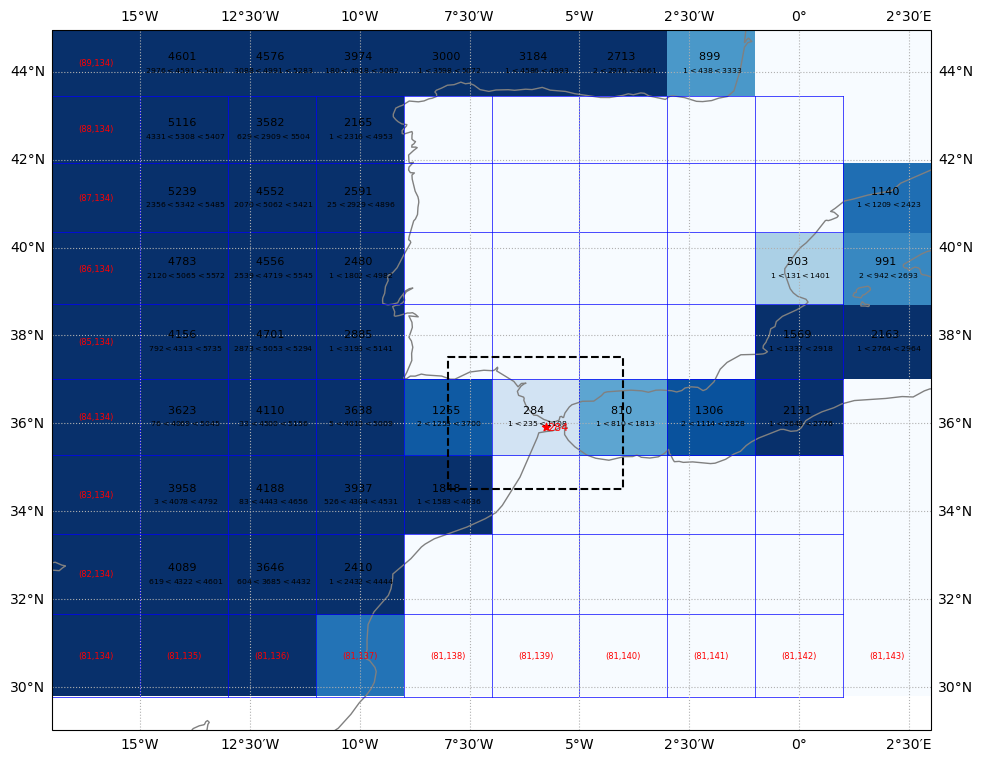

In [7]:
place = 'St. of Gibralter'
print(soc_table[place])
lon_beg = -15
lon_end = 5
lat_beg = 30
lat_end = 45
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,places=[place])

lon1 = -8
lat1 = 34.5
lon2 = -4.0
lat2 = 37.5
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')

In [8]:
width = 12.0e3
print('width = ',width)

with open(path_out+file_out_chan,'w') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  12000.0


### Bosphorus and Dardanelles Straits

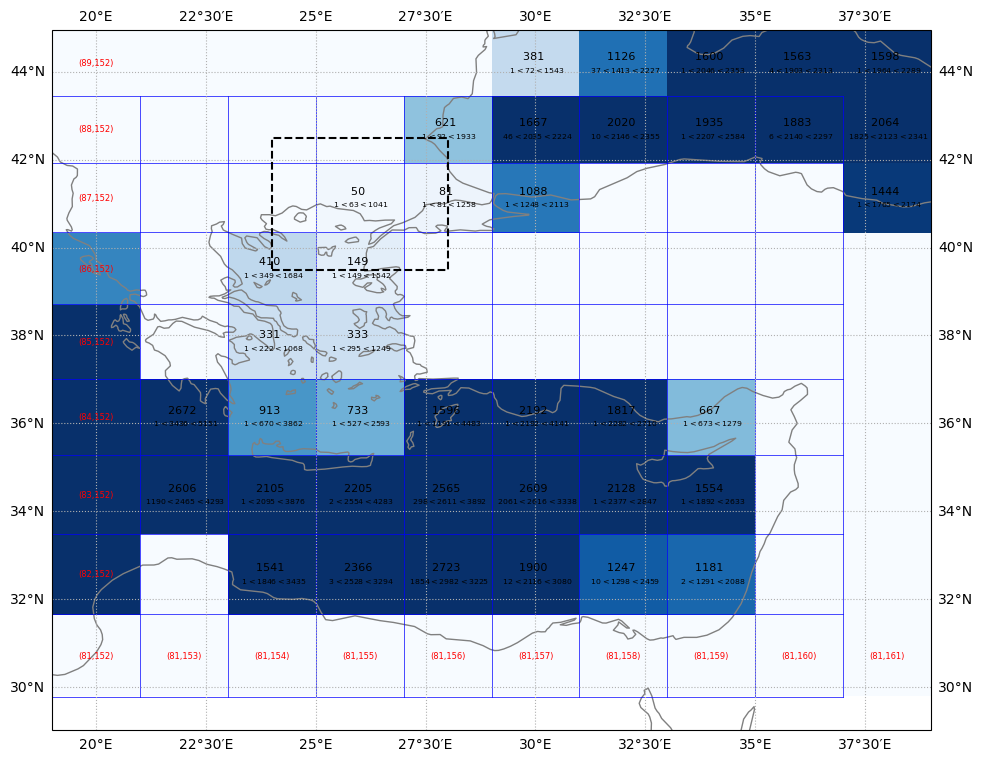

In [9]:
# Bosphorus Strait/Dardanelles Strait
place = 'Bosphorus/Dardanelles St.'
lon_beg = 20
lon_end = 40
lat_beg = 30
lat_end = 45
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

# The grid cell is displaced
lon1 = 24.0
lat1 = 39.5
lon2 = 28.0
lat2 = 42.5
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')

In [10]:
width = 5.0e3
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  5000.0


### Bab El-Mandeb Strait

{'lat': 13.73, 'lon': 42.5, 'depth': 137.0, 'width': 32.0}


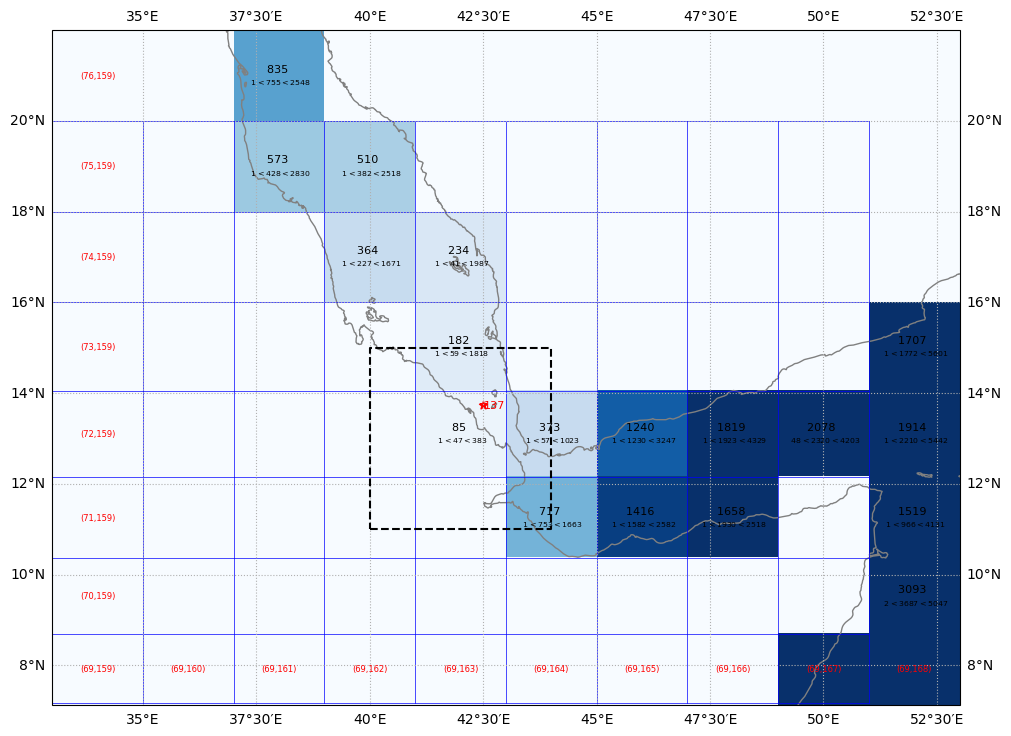

In [11]:
place = 'Bab El-Mandeb'
print(soc_table[place])
lon_beg = 35
lon_end = 55
lat_beg = 7.5
lat_end = 22.5
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,places=[place])

# The grid cell is displaced
lon1 = 40.0
lon2 = 44.0
lat1 = 11.0
lat2 = 15.0
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')

In [12]:
width = soc_table[place]['width']*1000.
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  32000.0


### Strait of Hormuz

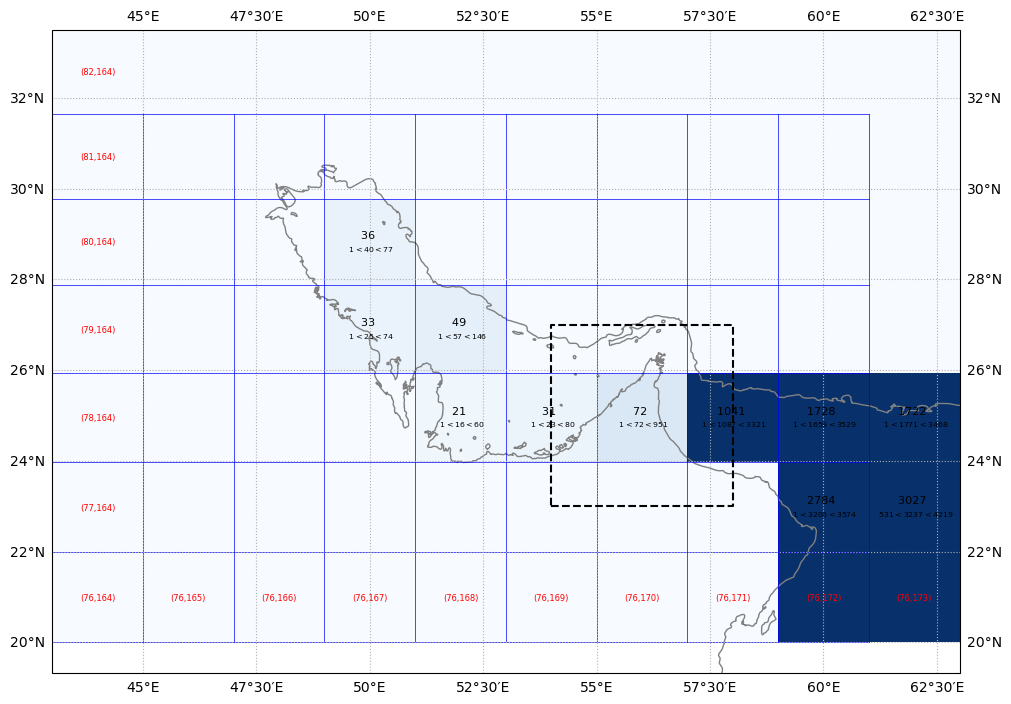

In [13]:
place ='St. of Hormuz'
lon_beg = 45
lon_end = 65
lat_beg = 20
lat_end = 35
zmax = 500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

# The grid cell is displaced
lon1 = 54.0
lon2 = 58.0
lat1 = 23.0
lat2 = 27.0
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')

In [14]:
width = 34.0e4
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  340000.0


### Malacca Strait and Sunda Strait

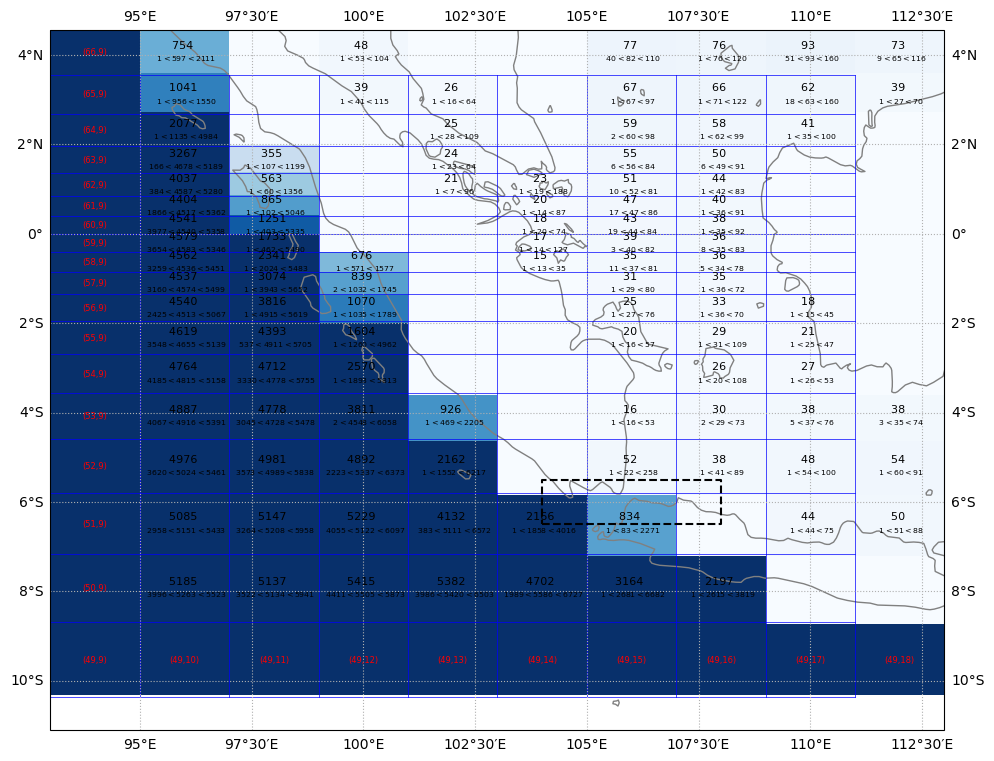

In [15]:
places = ['Malacca St.','Sunda St.']

lon_beg = -265.0
lon_end = -245.0
lat_beg = -10.0
lat_end = 5.0
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

# Malacca Strait: looks narrow enough

# Sunda Strait
lon1 = 104.0
lon2 = 108.0
lat1 = -6.5
lat2 = -5.5
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')

In [16]:
width = 24.0e3
print('width = ',width)

# Sunda Strait
with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,places[1])
    f.write(line)

width =  24000.0


### Lombok Strait, Sape Strait, and Ombai Strait

{'lat': -8.9, 'lon': 116.0, 'depth': 350.0, 'width': 22.0}
{'lat': -9.16, 'lon': 120.16, 'depth': 560.0, 'width': -1.0}


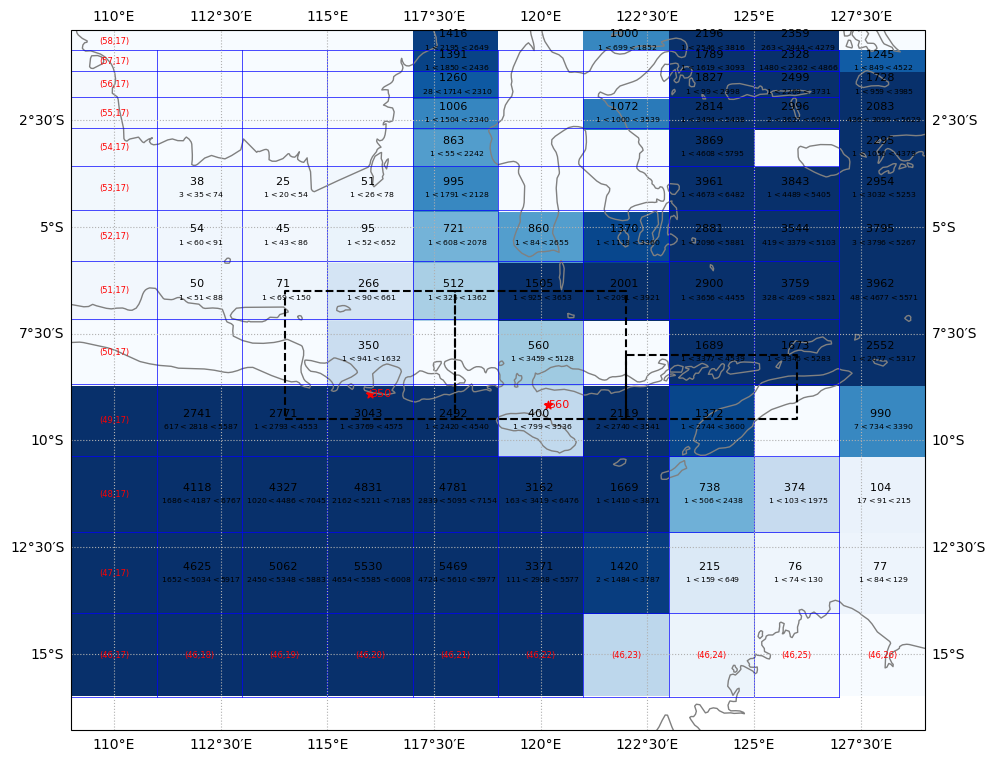

In [17]:
places = ['Lombok St.','Sumbas St']
for n in range(len(places)) :
    print(soc_table[places[n]])

lon_beg = -250.0
lon_end = -230.0
lat_beg = -15.0
lat_end = 0.0
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,places=places)

lon1 = [0] * 3
lon2 = [0] * 3
lat1 = [0] * 3
lat2 = [0] * 3

# Lombok Strait
lon1[0] = 114.0
lon2[0] = 118.0
lat1[0] = -9.5
lat2[0] = -6.5

# Sape Strait
lon1[1] = 118.0
lon2[1] = 122.0
lat1[1] = -9.5
lat2[1] = -6.5

# Ombai Strait
lon1[2] = 122.0
lon2[2] = 126.0
lat1[2] = -9.5
lat2[2] = -8.0

for n in range(0,3) :
    xbox = [lon1[n], lon2[n], lon2[n], lon1[n], lon1[n]]
    ybox = [lat1[n], lat1[n], lat2[n], lat2[n], lat1[n]]
    ax.plot(xbox,ybox,linestyle='dashed',color='k')

In [18]:
width = [22.0e3, 15.0e3, 27.0e3]
print('width = ',width)

places = ['Lombok St.','Sape St.','Ombai St.']

# Assuming all channels have the same width
for n in range(0,3) :
    with open(path_out+file_out_chan,'a') as f:
        line = fmt_out.format("V_width",lon1[n],lon2[n],lat1[n],lat2[n],width[n],places[n])
        f.write(line)

width =  22000.0
